In [28]:
file_dir = "../data/BD_METRO/Apprentissage.mat"
import scipy.io as sio

mat_data = sio.loadmat(file_dir)


mat_data['BD']


array([[   3,  426,  582,  838, 1020,    4],
       [   6,  919, 1039,  519,  637,    7],
       [   6,  755,  867,  523,  645,    1],
       [   6,  593,  711,  525,  643,    4],
       [   6,  919, 1039,  659,  777,   11],
       [   6,  757,  873,  665,  781,   14],
       [   9,  539,  597,  581,  639,    4],
       [   9,  621,  681,  581,  639,    1],
       [   9,  705,  763,  581,  637,    7],
       [   9,  621,  679,  649,  709,   14],
       [   9,  705,  763,  651,  709,   11],
       [  12,  811,  949,  497,  635,    7],
       [  12,  439,  569,  501,  635,    4],
       [  12,  621,  759,  501,  641,    1],
       [  12,  809,  949,  659,  799,   11],
       [  12,  619,  755,  663,  801,   14],
       [  15,  523,  595,  569,  643,    1],
       [  15,  421,  493,  571,  643,    4],
       [  15,  523,  595,  655,  727,   14],
       [  15,  625,  697,  655,  727,   11],
       [  18,  443,  575,  577,  721,    4],
       [  21,  631,  733,  603,  709,    1],
       [  

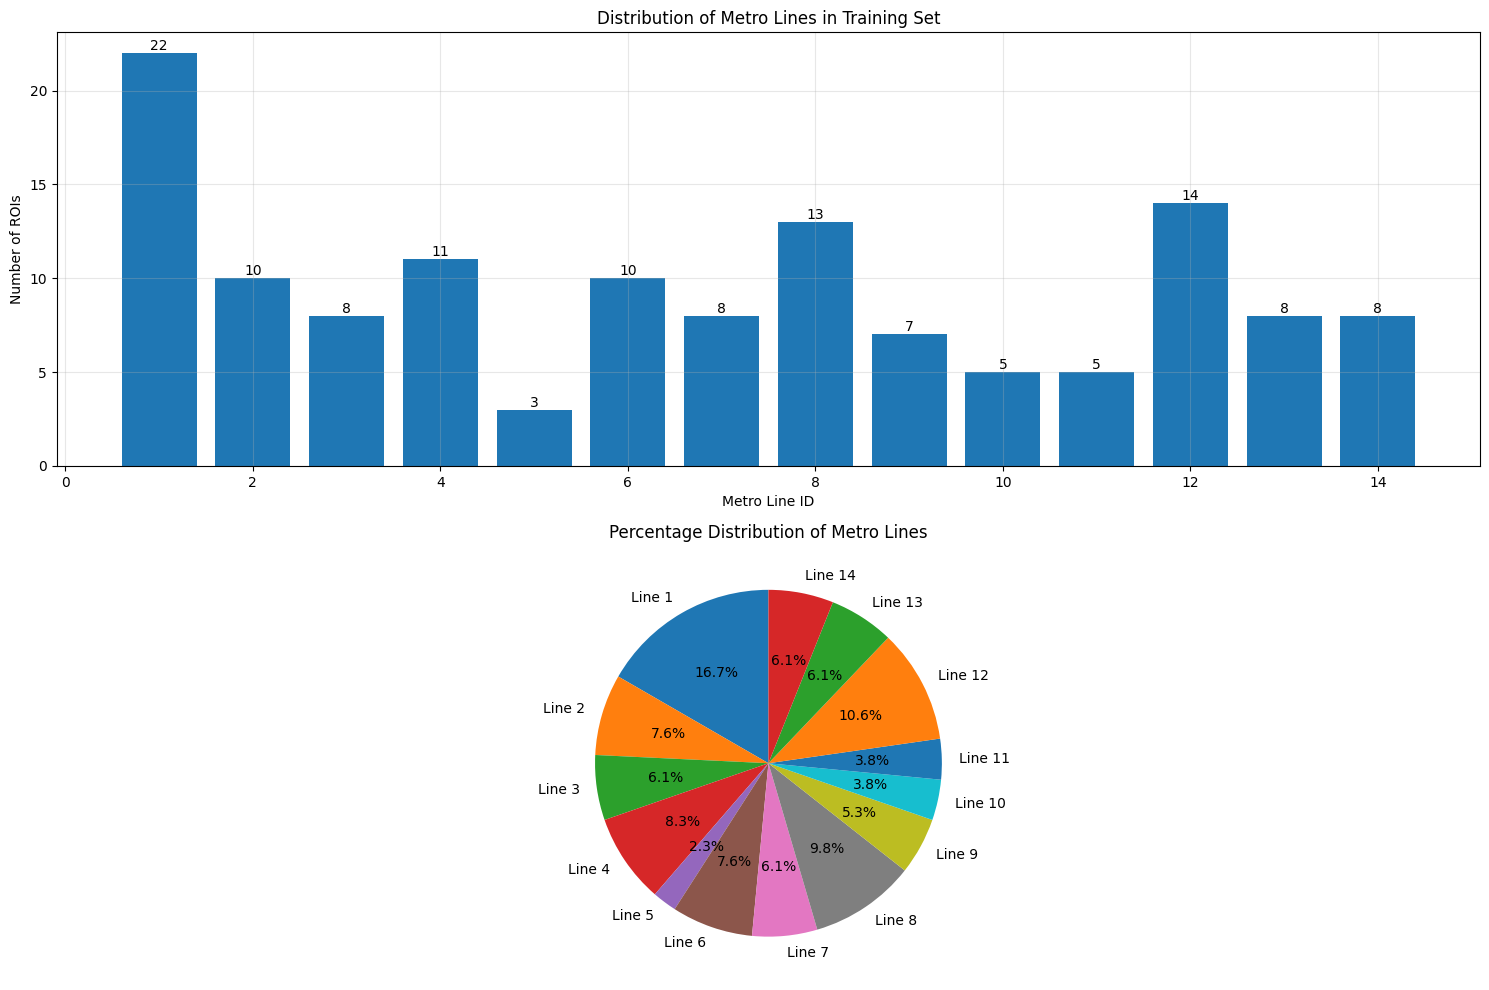


Metro Line Distribution Statistics:
--------------------------------------------------
Total ROIs in dataset: 132

Breakdown by line:
Line 1: 22 ROIs (16.7%)
Line 2: 10 ROIs (7.6%)
Line 3: 8 ROIs (6.1%)
Line 4: 11 ROIs (8.3%)
Line 5: 3 ROIs (2.3%)
Line 6: 10 ROIs (7.6%)
Line 7: 8 ROIs (6.1%)
Line 8: 13 ROIs (9.8%)
Line 9: 7 ROIs (5.3%)
Line 10: 5 ROIs (3.8%)
Line 11: 5 ROIs (3.8%)
Line 12: 14 ROIs (10.6%)
Line 13: 8 ROIs (6.1%)
Line 14: 8 ROIs (6.1%)


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

train_data = mat_data['BD']

# 统计每条线路的数量
line_counts = Counter(train_data[:, -1].astype(int))
sorted_lines = sorted(line_counts.items())
lines, counts = zip(*sorted_lines)

# 计算百分比
total_rois = len(train_data)
percentages = [count/total_rois * 100 for count in counts]

plt.figure(figsize=(15, 10))

# 子图1: 线路数量分布
plt.subplot(2, 1, 1)
bars = plt.bar(lines, counts)
plt.title('Distribution of Metro Lines in Training Set')
plt.xlabel('Metro Line ID')
plt.ylabel('Number of ROIs')

# 在柱状图上添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')
plt.grid(True, alpha=0.3)

# 子图2: 线路占比饼图
plt.subplot(2, 1, 2)
plt.pie(counts, labels=[f'Line {l}' for l in lines], 
        autopct='%1.1f%%',
        startangle=90)
plt.title('Percentage Distribution of Metro Lines')

plt.tight_layout()
plt.show()

# 打印统计信息
print("\nMetro Line Distribution Statistics:")
print("-" * 50)
print(f"Total ROIs in dataset: {total_rois}")
print("\nBreakdown by line:")
for line, count, percentage in zip(lines, counts, percentages):
    print(f"Line {int(line)}: {int(count)} ROIs ({percentage:.1f}%)")


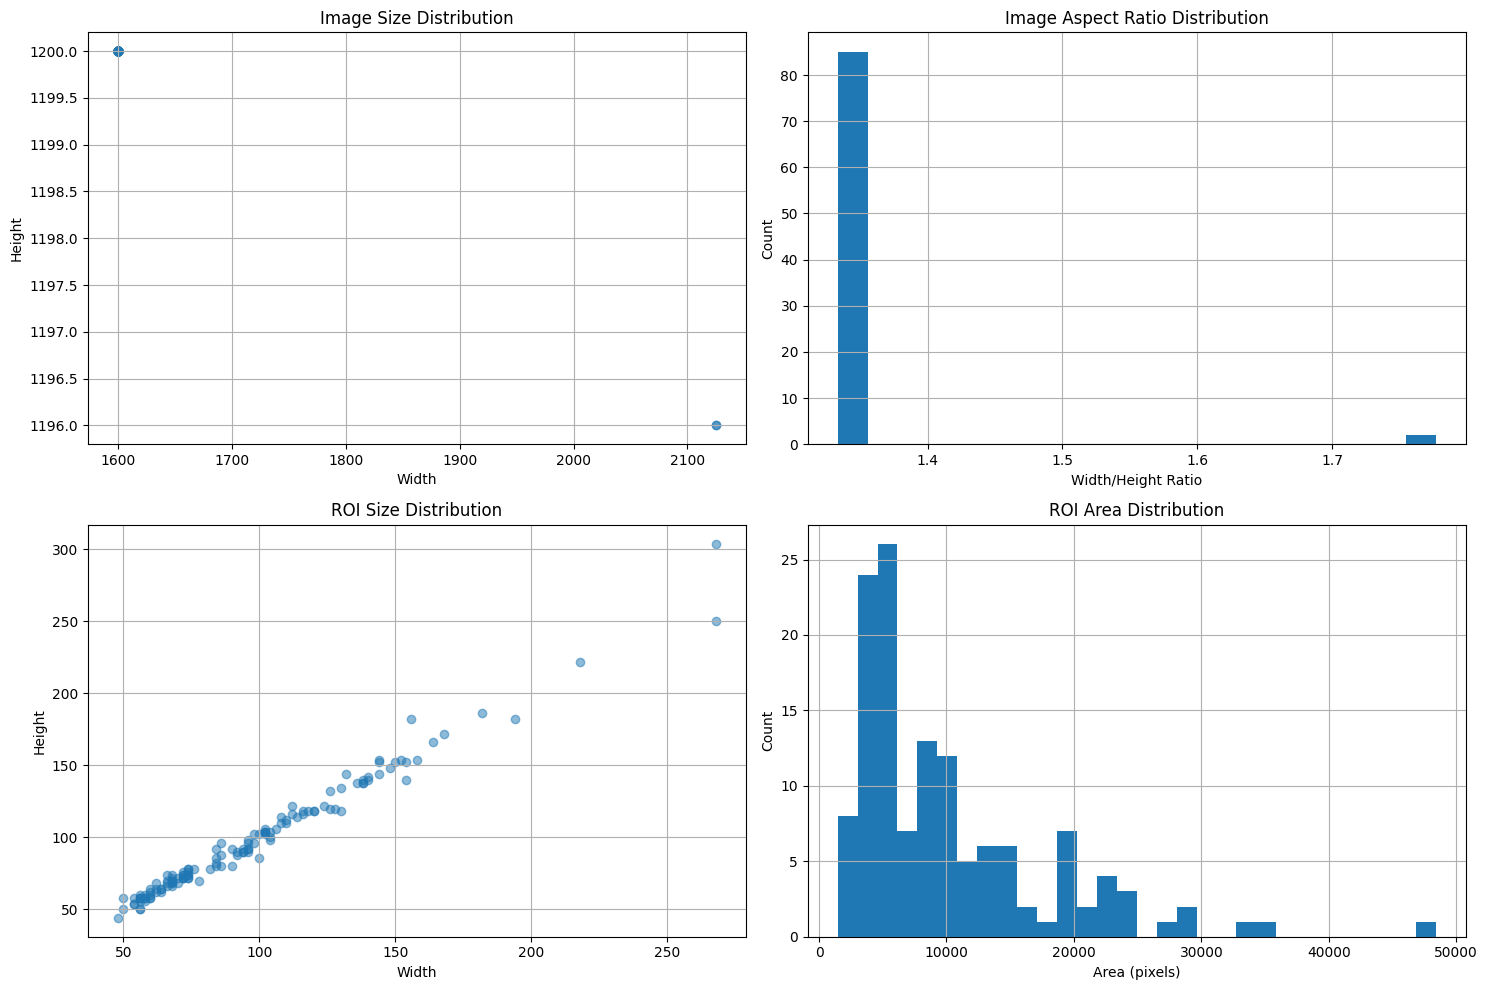


Image Size Statistics:
--------------------------------------------------
Number of images: 87
Average image size: [1612 1199]
Average aspect ratio: 1.34

ROI Size Statistics:
--------------------------------------------------
Number of ROIs: 132
Average ROI size: [97 97]
Average ROI area: 10189 pixels


In [30]:
# 读取训练图片并分析尺寸分布
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_img_dir = "../data/BD_METRO/"
train_img_paths = glob.glob(train_img_dir + "IM *.JPG")

img_sizes = []
roi_sizes = []
for img_path in train_img_paths:
    img_id = int(img_path.split("IM ")[-1].strip("()").split(".")[0].strip(")"))

    if img_id % 3 != 0:
        continue
        
    # 读取图像并记录尺寸
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    img_sizes.append((w, h))
    
    # 从mat_data['BD']获取对应的ROI标注
    img_rois = train_data[train_data[:,0] == img_id]
    
    # 计算ROI框尺寸
    for roi in img_rois:
        x1, x2, y1, y2 = roi[1:5]
        roi_w = x2 - x1
        roi_h = y2 - y1
        roi_sizes.append((roi_w, roi_h))

# 转换为numpy数组方便分析
img_sizes = np.array(img_sizes)
roi_sizes = np.array(roi_sizes)

plt.figure(figsize=(15, 10))

# 图像尺寸分布
plt.subplot(2,2,1)
plt.scatter(img_sizes[:,0], img_sizes[:,1], alpha=0.5)
plt.title('Image Size Distribution')
plt.xlabel('Width')
plt.ylabel('Height')
plt.grid(True)

# 图像宽高比分布
plt.subplot(2,2,2)
aspect_ratios = img_sizes[:,0] / img_sizes[:,1]
plt.hist(aspect_ratios, bins=20)
plt.title('Image Aspect Ratio Distribution')
plt.xlabel('Width/Height Ratio')
plt.ylabel('Count')
plt.grid(True)

# ROI尺寸分布
plt.subplot(2,2,3)
plt.scatter(roi_sizes[:,0], roi_sizes[:,1], alpha=0.5)
plt.title('ROI Size Distribution')
plt.xlabel('Width')
plt.ylabel('Height')
plt.grid(True)

# ROI面积分布
plt.subplot(2,2,4)
roi_areas = roi_sizes[:,0] * roi_sizes[:,1]
plt.hist(roi_areas, bins=30)
plt.title('ROI Area Distribution')
plt.xlabel('Area (pixels)')
plt.ylabel('Count')
plt.grid(True)

plt.tight_layout()
plt.show()

# 打印统计信息
print("\nImage Size Statistics:")
print("-" * 50)
print(f"Number of images: {len(img_sizes)}")
print(f"Average image size: {img_sizes.mean(axis=0).astype(int)}")
print(f"Average aspect ratio: {aspect_ratios.mean():.2f}")

print("\nROI Size Statistics:")
print("-" * 50) 
print(f"Number of ROIs: {len(roi_sizes)}")
print(f"Average ROI size: {roi_sizes.mean(axis=0).astype(int)}")
print(f"Average ROI area: {roi_areas.mean():.0f} pixels")


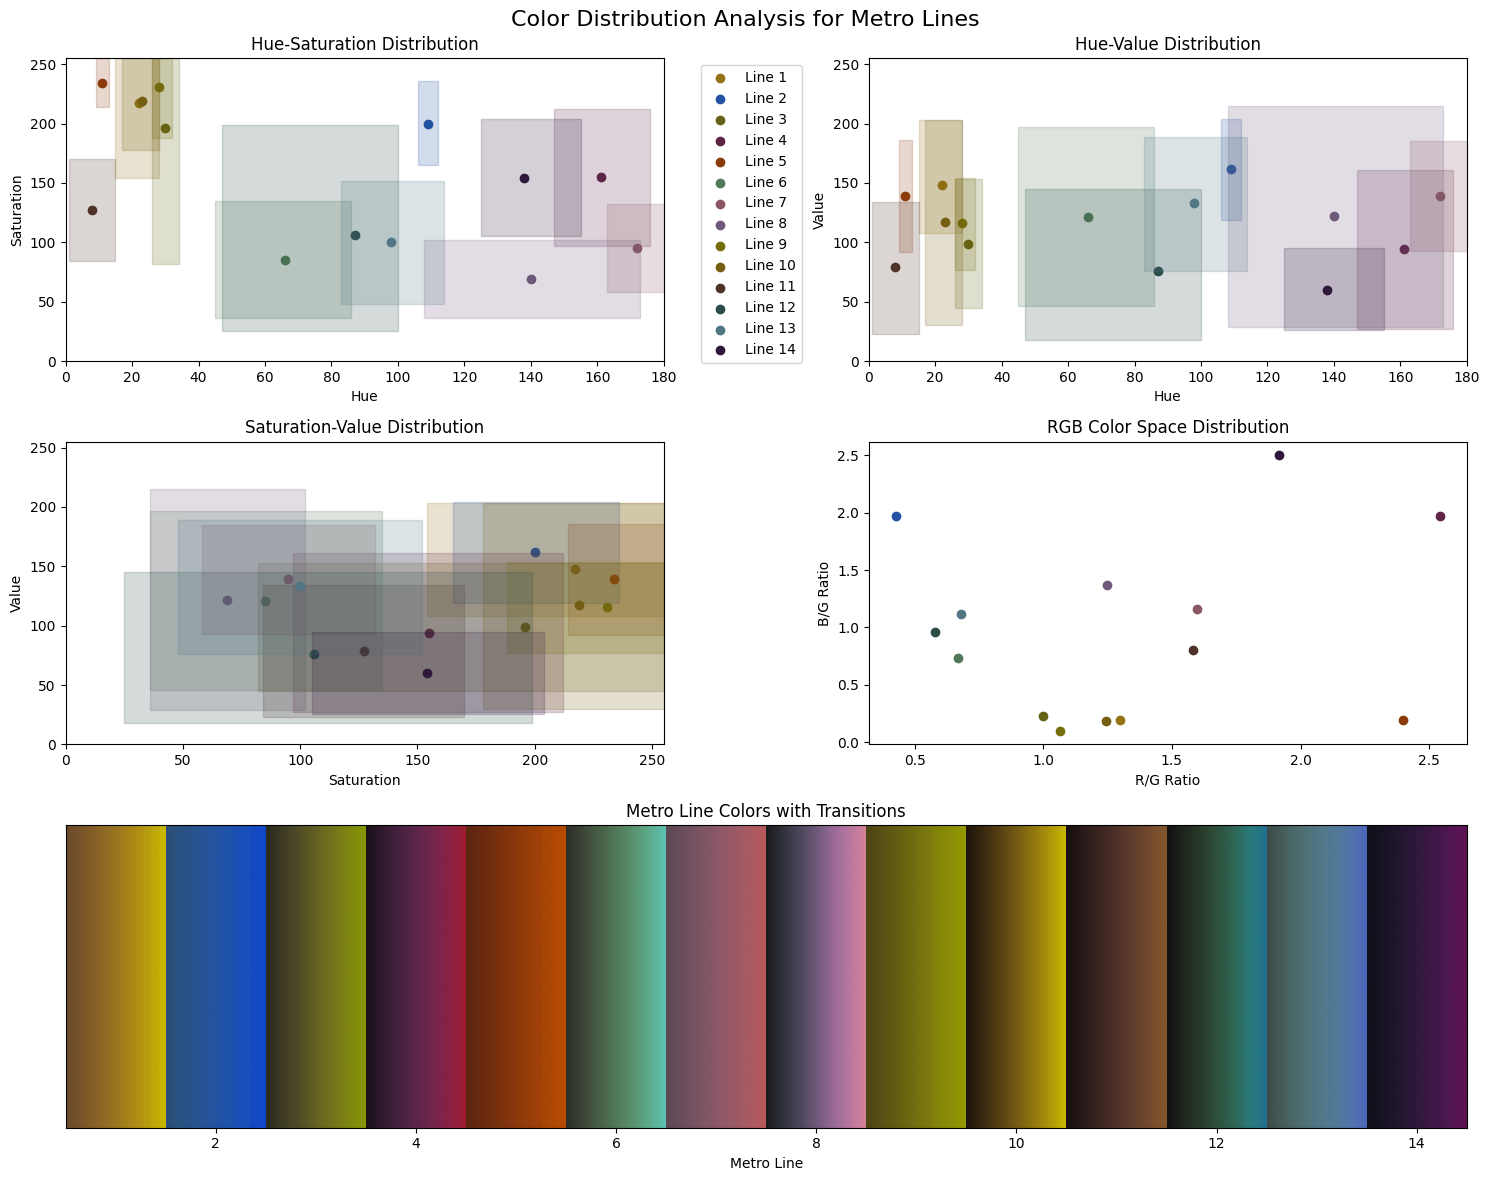

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import json
import cv2

color_params = json.load(open('../models/roi_detection/no_gray_with_filter.json'))

# 创建HSV和RGB颜色字典
line_colors = {}
for line_id in range(1,15):
    line_id = str(line_id)
    hsv_mean = np.array(color_params[line_id]['hsv_mean'])
    hsv_std = np.array(color_params[line_id]['hsv_std'])
    hsv_lower = np.array(color_params[line_id]['hsv_lower'])
    hsv_upper = np.array(color_params[line_id]['hsv_upper'])
    
    # 转换HSV到RGB
    rgb_mean = cv2.cvtColor(np.uint8([[hsv_mean]]), cv2.COLOR_HSV2RGB)[0][0]
    rgb_lower = cv2.cvtColor(np.uint8([[hsv_lower]]), cv2.COLOR_HSV2RGB)[0][0] 
    rgb_upper = cv2.cvtColor(np.uint8([[hsv_upper]]), cv2.COLOR_HSV2RGB)[0][0]
    
    line_colors[line_id] = {
        'hsv_mean': hsv_mean,
        'hsv_std': hsv_std,
        'hsv_lower': hsv_lower,
        'hsv_upper': hsv_upper,
        'rgb_mean': rgb_mean,
        'rgb_lower': rgb_lower,
        'rgb_upper': rgb_upper
    }

# 创建可视化图表
fig = plt.figure(figsize=(15, 12))
fig.suptitle('Color Distribution Analysis for Metro Lines', fontsize=16)

# HSV分布
ax1 = plt.subplot2grid((3,2), (0,0))
ax2 = plt.subplot2grid((3,2), (0,1))
ax3 = plt.subplot2grid((3,2), (1,0))
ax4 = plt.subplot2grid((3,2), (1,1))
ax5 = plt.subplot2grid((3,2), (2,0), colspan=2)

# H-S 分布
ax1.set_title('Hue-Saturation Distribution')
ax1.set_xlabel('Hue')
ax1.set_ylabel('Saturation')
ax1.set_xlim(0, 180)
ax1.set_ylim(0, 255)

# H-V 分布
ax2.set_title('Hue-Value Distribution')
ax2.set_xlabel('Hue')
ax2.set_ylabel('Value')
ax2.set_xlim(0, 180)
ax2.set_ylim(0, 255)

# S-V 分布
ax3.set_title('Saturation-Value Distribution')
ax3.set_xlabel('Saturation')
ax3.set_ylabel('Value')
ax3.set_xlim(0, 255)
ax3.set_ylim(0, 255)

# RGB分布
ax4.set_title('RGB Color Space Distribution')
ax4.set_xlabel('R/G Ratio')
ax4.set_ylabel('B/G Ratio')

# 颜色带展示
ax5.set_title('Metro Line Colors with Transitions')
ax5.set_xlabel('Metro Line')
ax5.set_yticks([])

# 绘制每条线路的分布
for line_id in line_colors:
    color = line_colors[line_id]
    rgb_color = color['rgb_mean']/255.0  # Normalize to [0,1]
    
    # H-S plot
    rect = Rectangle(
        (color['hsv_lower'][0], color['hsv_lower'][1]),
        color['hsv_upper'][0] - color['hsv_lower'][0],
        color['hsv_upper'][1] - color['hsv_lower'][1],
        alpha=0.2,
        color=rgb_color
    )
    ax1.add_patch(rect)
    ax1.scatter(color['hsv_mean'][0], color['hsv_mean'][1], 
                color=rgb_color, label=f'Line {line_id}')
    
    # H-V plot
    rect = Rectangle(
        (color['hsv_lower'][0], color['hsv_lower'][2]),
        color['hsv_upper'][0] - color['hsv_lower'][0],
        color['hsv_upper'][2] - color['hsv_lower'][2],
        alpha=0.2,
        color=rgb_color
    )
    ax2.add_patch(rect)
    ax2.scatter(color['hsv_mean'][0], color['hsv_mean'][2], color=rgb_color)
    
    # S-V plot
    rect = Rectangle(
        (color['hsv_lower'][1], color['hsv_lower'][2]),
        color['hsv_upper'][1] - color['hsv_lower'][1],
        color['hsv_upper'][2] - color['hsv_lower'][2],
        alpha=0.2,
        color=rgb_color
    )
    ax3.add_patch(rect)
    ax3.scatter(color['hsv_mean'][1], color['hsv_mean'][2], color=rgb_color)
    
    # RGB ratios plot
    rgb = color['rgb_mean']
    rg_ratio = rgb[0]/max(rgb[1],1)  # Avoid division by 0
    bg_ratio = rgb[2]/max(rgb[1],1)
    ax4.scatter(rg_ratio, bg_ratio, color=rgb_color, label=f'Line {line_id}')
    
    # 创建颜色渐变
    x = np.linspace(int(line_id)-0.5, int(line_id)+0.5, 100)
    y = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(x, y)
    
    # 生成HSV渐变色
    hsv_gradient = np.zeros((100, 100, 3))
    for i in range(100):
        t = i / 99.0  # 归一化参数 [0,1]
        # HSV线性插值
        hsv = color['hsv_lower'] * (1-t) + color['hsv_upper'] * t
        # 转换为RGB
        rgb = cv2.cvtColor(np.uint8([[hsv]]), cv2.COLOR_HSV2RGB)[0][0]
        hsv_gradient[:,i] = rgb / 255.0

    ax5.imshow(hsv_gradient, extent=[int(line_id)-0.5, int(line_id)+0.5, 0, 1], aspect='auto')

ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax5.set_xlim(0.5, 14.5)
ax5.set_ylim(0, 1)

plt.tight_layout()
plt.show()
